# Experimenting with KDE and true pdf with Edge count simulations

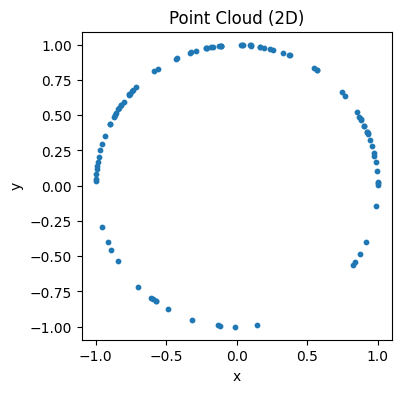

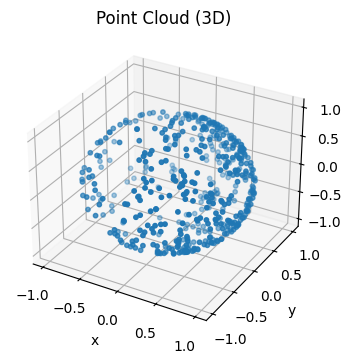

In [78]:
import numpy as np
import ecc_vr as vr
import matplotlib.pyplot as plt

def hemisphere_biased_hypersphere(
    n_points,
    d,
    p=0.8,
    r=1.0,
    center=None,
    direction=None,
    seed=None,
    shuffle=True,
):
    # p = fraction of points in the hemisphere
    # {x : <x - center, direction> >= 0}

    if d < 2:
        raise ValueError("d must be at least 2")
    if not (0.0 <= p <= 1.0):
        raise ValueError("p must be between 0 and 1")

    rng = np.random.default_rng(seed)

    if direction is None:
        direction = np.zeros(d)
        direction[0] = 1.0

    direction = np.asarray(direction, dtype=float)
    if direction.shape != (d,):
        raise ValueError(f"direction must have shape ({d},)")

    direction_norm = np.linalg.norm(direction)
    if direction_norm == 0:
        raise ValueError("direction must be non-zero")
    direction = direction / direction_norm

    def sample_uniform_sphere(m):
        X = rng.normal(size=(m, d))
        norms = np.linalg.norm(X, axis=1, keepdims=True)

        while np.any(norms == 0):
            bad = norms[:, 0] == 0
            X[bad] = rng.normal(size=(bad.sum(), d))
            norms[bad] = np.linalg.norm(X[bad], axis=1, keepdims=True)

        return X / norms

    n_side = int(round(p * n_points))
    n_other = n_points - n_side

    # sample points for the chosen hemisphere
    X_side = sample_uniform_sphere(n_side)
    dots_side = X_side @ direction
    X_side[dots_side < 0] *= -1.0

    # sample points for the opposite hemisphere
    X_other = sample_uniform_sphere(n_other)
    dots_other = X_other @ direction
    X_other[dots_other > 0] *= -1.0

    X = np.vstack([X_side, X_other])

    if shuffle:
        rng.shuffle(X, axis=0)

    X *= r

    if center is not None:
        center = np.asarray(center, dtype=float)
        if center.shape != (d,):
            raise ValueError(f"center must have shape ({d},)")
        X += center

    return X

C = hemisphere_biased_hypersphere(
    n_points = 100,
    d = 2,
    p = 0.8,
    direction = [0,1],
    seed = None,
)
fig = plt.figure(figsize = (4,4))
ax = fig.add_subplot(111)
vr.plot_point_cloud_on_ax(ax, C, 2)
plt.show()

C2 = hemisphere_biased_hypersphere(
    n_points=500,
    d=3,
    p=0.8,          # 80% on one side
    direction=[1, 0, 0],      # which side
    seed=None,
)

 # look into normal distribution wrapped around circle (directional data) (pdfs and distributions on directional data)
fig2 = plt.figure(figsize = (4,4))
ax2 = fig2.add_subplot(111, projection = '3d')
vr.plot_point_cloud_on_ax(ax2, C2, 3)
plt.show()


In [79]:
def count_edges(X: np.ndarray, t: float, D: np.ndarray | None = None) -> int:
    X = np.asarray(X, dtype = float)

    epsilon = t/(X.shape[0]**(1/(X.shape[1]-1)))

    if D is None:
        D = vr.pairwise_dist(X)
    
    edge_count = int(np.count_nonzero(np.triu(D <= epsilon, k = 1)))
    return edge_count



# How to get pdf for n-dim hypershpere?

If points live in $\mathbb{R}^d$, then hypersphere surface is $S^{(d-1)}$, and density should be with respect to surface area on the sphere. For this hemisphere-biased model, the true pdf is piecewise constant $\frac{2p}{\text{area}}$ on the chosen hemisphere and $\frac{2(1-p)}{\text{area}}$ on the opposite hemisphere.

In [80]:
import math

def hypersphere_surface_area(d, r=1.0):
    if d < 2:
        raise ValueError("d must be at least 2")
    if r <= 0:
        raise ValueError("r must be positive")

    log_area = (
        math.log(2.0)
        + 0.5 * d * math.log(math.pi)
        + (d - 1) * math.log(r)
        - math.lgamma(d / 2.0)
    )
    return math.exp(log_area)


def hemisphere_biased_hypersphere_pdf(
    C,
    p = 0.8,
    r = 1.0,
    center = None,
    direction = None,
    tol = 1e-8,
):
    C = np.asarray(C, dtype=float)

    if C.ndim != 2:
        raise ValueError("C must have shape (n_points, d)")

    n_points, d = C.shape

    if not (0.0 <= p <= 1.0):
        raise ValueError("p must be between 0 and 1")

    if center is None:
        center = np.zeros(d)
    center = np.asarray(center, dtype=float)
    if center.shape != (d,):
        raise ValueError(f"center must have shape ({d},)")

    if direction is None:
        direction = np.zeros(d)
        direction[0] = 1.0
    direction = np.asarray(direction, dtype=float)
    if direction.shape != (d,):
        raise ValueError(f"direction must have shape ({d},)")

    direction_norm = np.linalg.norm(direction)
    if direction_norm == 0:
        raise ValueError("direction must be non-zero")
    direction = direction / direction_norm

    shifted = C - center
    radii = np.linalg.norm(shifted, axis=1)
    on_sphere = np.abs(radii - r) <= tol

    dots = shifted @ direction
    area = hypersphere_surface_area(d, r)

    pdf_vals = np.zeros(n_points, dtype=float)
    pdf_vals[on_sphere & (dots >= 0)] = 2.0 * p / area
    pdf_vals[on_sphere & (dots < 0)] = 2.0 * (1.0 - p) / area

    return pdf_vals

#Example Usage

C2 = hemisphere_biased_hypersphere(
    n_points=50,
    d=3,
    p=0.8,          # 80% on one side
    direction=[1, 0, 0],      # which side
    seed=None,
)

true_pdf = hemisphere_biased_hypersphere_pdf(
    C2,
    p=0.8,
    direction=[1, 0, 0],
)
print(true_pdf)

[0.12732395 0.12732395 0.03183099 0.12732395 0.12732395 0.12732395
 0.03183099 0.03183099 0.03183099 0.12732395 0.12732395 0.12732395
 0.12732395 0.12732395 0.12732395 0.12732395 0.12732395 0.03183099
 0.12732395 0.12732395 0.12732395 0.12732395 0.12732395 0.12732395
 0.12732395 0.03183099 0.12732395 0.12732395 0.12732395 0.03183099
 0.12732395 0.12732395 0.12732395 0.12732395 0.03183099 0.12732395
 0.12732395 0.12732395 0.12732395 0.12732395 0.12732395 0.12732395
 0.03183099 0.12732395 0.12732395 0.12732395 0.03183099 0.12732395
 0.12732395 0.12732395]


In [81]:
#implementing real pdf into distance matrix adjustment

def weighted_distance_matrix_pdf(
    X,
    p=0.8,
    r=1.0,
    center=None,
    direction=None,
    d_manifold=1,
    sym_rule="mean",
    tol=1e-8,
):
  
    X = np.asarray(X, dtype=float)

    D = vr.pairwise_dist(X)

    f = hemisphere_biased_hypersphere_pdf(
        X,
        p=p,
        r=r,
        center=center,
        direction=direction,
        tol=tol,
    )

    f = np.maximum(f, 1e-12)   # guard against zero density
    f = f / f.mean()
    s = f ** (1.0 / d_manifold)   # (n,)

    si = s[:, None]
    sj = s[None, :]

    rule = sym_rule.lower().strip()
    if rule == "min":
        scale = np.maximum(si, sj)
    elif rule == "max":
        scale = np.minimum(si, sj)
    elif rule in {"mean", "avg", "average"}:
        scale = (si * sj) / (si + sj)
    else:
        raise ValueError("sym_rule must be 'min', 'max', or 'mean'")

    
    D_w = D * scale
    np.fill_diagonal(D_w, 0.0)
    return D_w, scale



# it should be norm less than t of n to 1 over d time ( 1 over kde(xi)^1/d)+ 1

In [94]:
print(f"Non adjusted edge count for circle above (t=1): {count_edges(C, t=1.5)}.")
print(f"Non adjusted edge count for sphere above (t=1): {count_edges(C2, t=1.5)}.\n")

Dw_circleK, a,  = vr.weighted_distance_matrix_kde(C, h=0.15, d_manifold=1, sym_rule="mean")
Dw_sphereK,a2 = vr.weighted_distance_matrix_kde(C2, h=0.15, d_manifold =2 , sym_rule="mean")

print(f"KDE adjusted edge count for circle above (t = 1, h = 0.15): {count_edges(C, t=3,D=Dw_circleK)}.")
print(f"KDE adjusted edge count for sphere above (t = 1, h = 0.15): {count_edges(C2, t=3,D=Dw_sphereK)}.\n")

Dw_circle, _ = weighted_distance_matrix_pdf(C, d_manifold=1, p = 0.8, sym_rule="mean")
Dw_sphere, _= weighted_distance_matrix_pdf(C2, d_manifold=2, p = 0.8,sym_rule="mean" )

print(f"PDF adjusted edge count for circle above (t = 1): {count_edges(C, t=3,D=Dw_circle)}.")
print(f"PDF adjusted edge count for sphere above (t = 1): {count_edges(C2, t=3,D=Dw_sphere)}.")


_, scale_circle_K= vr.weighted_distance_matrix_kde(C, h=0.15, d_manifold=1, sym_rule="mean")
_, scale_sphere_K= vr.weighted_distance_matrix_kde(C2, h=0.15, d_manifold =2 , sym_rule="mean")

_,scale_circle_pdf= weighted_distance_matrix_pdf(C, d_manifold=1, p = 0.8, sym_rule="mean")
_,scale_sphere_pdf= weighted_distance_matrix_pdf(C2, d_manifold=2, p = 0.8,sym_rule="mean" )



distance = scale_circle_K - scale_circle_pdf
#print(np.sort(distance))
positive = distance >= 0
#print(positive)
np.shape(positive)#
np.count_nonzero(positive)







Non adjusted edge count for circle above (t=1): 37.
Non adjusted edge count for sphere above (t=1): 18.

KDE adjusted edge count for circle above (t = 1, h = 0.15): 63.
KDE adjusted edge count for sphere above (t = 1, h = 0.15): 72.

PDF adjusted edge count for circle above (t = 1): 209.
PDF adjusted edge count for sphere above (t = 1): 316.


np.int64(9052)

In [83]:
def edge_count_sim(
    n_points: int,
    t: float,
    n_resamples: int,
    d: int,
    p: float,
    direction=None,
    seed: int | None = None,
) -> np.ndarray:
    rng = np.random.default_rng(seed)
    edge_counts = np.empty(n_resamples, dtype=int)

    for i in range(n_resamples):
        sample_seed = int(rng.integers(0, 1_000_000_000))

        C = hemisphere_biased_hypersphere(
            n_points=n_points,
            d=d,
            p=p,
            direction=direction,
            seed=sample_seed,
        )

        edge_counts[i] = count_edges(C, t=t)

    return edge_counts


def edge_count_sim_kde(
    n_points: int,
    t: float,
    n_resamples: int,
    d: int,
    p: float,
    h: float,
    direction=None,
    sym_rule="mean",
    seed: int | None = None,
) -> np.ndarray:
    rng = np.random.default_rng(seed)
    edge_counts = np.empty(n_resamples, dtype=int)

    for i in range(n_resamples):
        sample_seed = int(rng.integers(0, 1_000_000_000))

        C = hemisphere_biased_hypersphere(
            n_points=n_points,
            d=d,
            p=p,
            direction=direction,
            seed=sample_seed,
        )

        Dw, _ = vr.weighted_distance_matrix_kde(
            C,
            h=h,
            d_manifold=d - 1,
            sym_rule=sym_rule,
        )

        edge_counts[i] = count_edges(C, t=t, D=Dw)

    return edge_counts


def edge_count_sim_pdf(
    n_points: int,
    t: float,
    n_resamples: int,
    d: int,
    p: float,
    direction=None,
    sym_rule="mean",
    r: float = 1.0,
    center=None,
    tol: float = 1e-8,
    seed: int | None = None,
) -> np.ndarray:
    rng = np.random.default_rng(seed)
    edge_counts = np.empty(n_resamples, dtype=int)

    for i in range(n_resamples):
        sample_seed = int(rng.integers(0, 1_000_000_000))

        C = hemisphere_biased_hypersphere(
            n_points=n_points,
            d=d,
            p=p,
            r=r,
            center=center,
            direction=direction,
            seed=sample_seed,
        )

        Dw, _ = weighted_distance_matrix_pdf(
            C,
            p=p,
            r=r,
            center=center,
            direction=direction,
            d_manifold=d - 1,
            sym_rule=sym_rule,
            tol=tol,
        )

        edge_counts[i] = count_edges(C, t=t, D=Dw)

    return edge_counts


n_points = 50
     raw | mean = 7.95 | sd = 2.93 | median = 8.00 | 95% interval = [3.00, 14.52]
     kde | mean = 6.02 | sd = 2.61 | median = 6.00 | 95% interval = [2.00, 12.00]
     pdf | mean = 32.80 | sd = 5.64 | median = 32.50 | 95% interval = [23.00, 44.00]

n_points = 100
     raw | mean = 16.82 | sd = 4.29 | median = 17.00 | 95% interval = [9.00, 25.52]
     kde | mean = 12.89 | sd = 3.63 | median = 13.00 | 95% interval = [6.00, 20.00]
     pdf | mean = 67.03 | sd = 8.25 | median = 66.00 | 95% interval = [51.48, 84.00]

n_points = 250
     raw | mean = 41.92 | sd = 6.70 | median = 41.00 | 95% interval = [30.00, 57.52]
     kde | mean = 35.70 | sd = 5.81 | median = 35.00 | 95% interval = [25.00, 48.00]
     pdf | mean = 170.00 | sd = 13.35 | median = 170.00 | 95% interval = [144.00, 196.00]

n_points = 500
     raw | mean = 84.33 | sd = 8.63 | median = 84.00 | 95% interval = [69.00, 103.00]
     kde | mean = 76.29 | sd = 8.01 | median = 76.00 | 95% interval = [62.00, 93.00]
    

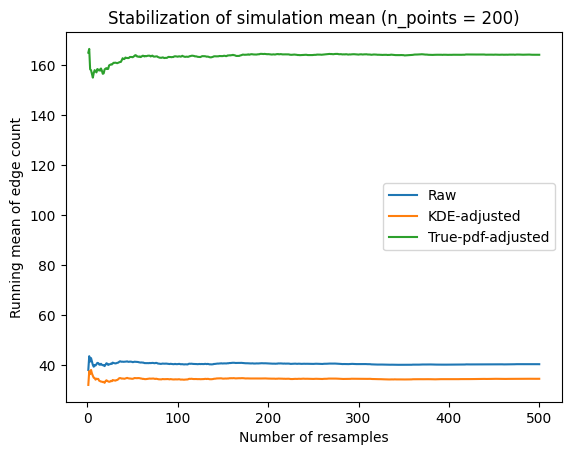

In [84]:
def summarize_counts(label, counts):
    mean = counts.mean()
    sd = counts.std(ddof=1)
    q025, q50, q975 = np.quantile(counts, [0.025, 0.5, 0.975])

    print(
        f"{label:>8} | mean = {mean:.2f} | sd = {sd:.2f} | "
        f"median = {q50:.2f} | 95% interval = [{q025:.2f}, {q975:.2f}]"
    )


for n_points in [50, 100, 250,500]:
    print(f"\nn_points = {n_points}")

    edge_counts_raw = edge_count_sim(
        n_points=n_points,
        t=1,
        n_resamples=500,
        d=3,
        p=0.8,
        direction=[1, 0, 0],
        seed=234,
    )

    edge_counts_kde = edge_count_sim_kde(
        n_points=n_points,
        t=1,
        n_resamples=500,
        d=3,
        p=0.8,
        h=0.15,
        direction=[1, 0, 0],
        sym_rule="mean",
        seed=234,
    )

    edge_counts_pdf = edge_count_sim_pdf(
        n_points=n_points,
        t=1,
        n_resamples=500,
        d=3,
        p=0.8,
        direction=[1, 0, 0],
        sym_rule="mean",
        seed=234,
    )

    summarize_counts("raw", edge_counts_raw)
    summarize_counts("kde", edge_counts_kde)
    summarize_counts("pdf", edge_counts_pdf)


# running mean comparison for one fixed n_points
n_points = 200
n_resamples = 500

edge_counts_raw = edge_count_sim(
    n_points=n_points,
    t=1,
    n_resamples=n_resamples,
    d=3,
    p=0.9,
    direction=[1, 0, 0],
    seed=234,
)

edge_counts_kde = edge_count_sim_kde(
    n_points=n_points,
    t=1,
    n_resamples=n_resamples,
    d=3,
    p=0.9,
    h=0.15,
    direction=[1, 0, 0],
    sym_rule="mean",
    seed=234,
)

edge_counts_pdf = edge_count_sim_pdf(
    n_points=n_points,
    t=1,
    n_resamples=n_resamples,
    d=3,
    p=0.9,
    direction=[1, 0, 0],
    sym_rule="mean",
    seed=234,
)

k = np.arange(1, n_resamples + 1)

running_mean_raw = np.cumsum(edge_counts_raw) / k
running_mean_kde = np.cumsum(edge_counts_kde) / k
running_mean_pdf = np.cumsum(edge_counts_pdf) / k

plt.plot(k, running_mean_raw, label="Raw")
plt.plot(k, running_mean_kde, label="KDE-adjusted")
plt.plot(k, running_mean_pdf, label="True-pdf-adjusted")
plt.xlabel("Number of resamples")
plt.ylabel("Running mean of edge count")
plt.title("Stabilization of simulation mean (n_points = 200)")
plt.legend()
plt.show()

Shapiro-Wilk p-value for 500 points and t = 1: 0.3849904890490224


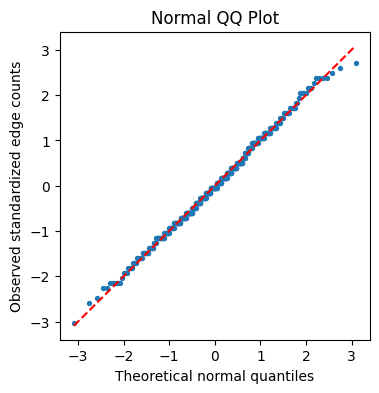

Shapiro-Wilk p-value for 500 points and t = 1: 0.01389229826769202


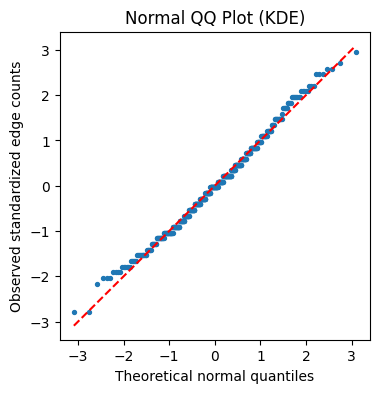

Shapiro-Wilk p-value for 500 points and t = 1: 0.022788319738430908


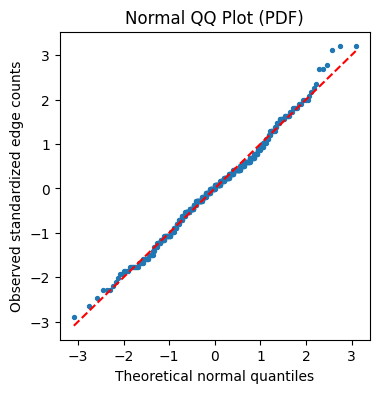

In [85]:
from scipy.stats import shapiro
from statistics import NormalDist


counts = edge_count_sim(
    n_points=500,
    t=1,
    n_resamples=500,
    d=3,
    p=0.8,
    direction=[1, 0, 0],
    seed=42,
    )

mu = counts.mean()

sd = counts.std(ddof=1)
    

z = np.sort((counts - mu) / sd)

p_vals = (np.arange(1, len(z) + 1) - 0.5) / len(z)
q = np.array([NormalDist().inv_cdf(pi) for pi in p_vals])


stat, p= shapiro(counts)
print(f"Shapiro-Wilk p-value for 500 points and t = 1:", p)

fig = plt.figure(figsize=(4, 4))
plt.scatter(q, z, s=8)
plt.plot([q.min(), q.max()], [q.min(), q.max()], "r--")
plt.xlabel("Theoretical normal quantiles")
plt.ylabel("Observed standardized edge counts")
plt.title("Normal QQ Plot")
plt.show()

counts2 = edge_count_sim_kde(
    n_points=500,
    t=1,
    n_resamples=500,
    d=3,
    p=0.8,
    h=0.15,
    direction=[1, 0, 0],
    sym_rule="mean",
    seed=234,
)
mu2 = counts2.mean()

sd2 = counts2.std(ddof=1)
    

z2 = np.sort((counts2 - mu2) / sd2)

p_vals2 = (np.arange(1, len(z) + 1) - 0.5) / len(z2)
q2= np.array([NormalDist().inv_cdf(pi) for pi in p_vals2])

stat2, p2= shapiro(counts2)
print(f"Shapiro-Wilk p-value for 500 points and t = 1:", p2)

fig2 = plt.figure(figsize=(4, 4))
plt.scatter(q2, z2, s=8)
plt.plot([q2.min(), q2.max()], [q2.min(), q2.max()], "r--")
plt.xlabel("Theoretical normal quantiles")
plt.ylabel("Observed standardized edge counts")
plt.title("Normal QQ Plot (KDE)")
plt.show()

counts3 = edge_count_sim_pdf(
    n_points=n_points,
    t=1,
    n_resamples=n_resamples,
    d=3,
    p=0.8,
    direction=[1, 0, 0],
    sym_rule="mean",
    seed=234,
)

mu3 = counts3.mean()

sd3 = counts3.std(ddof=1)
    

z3 = np.sort((counts3 - mu3) / sd3)

p_vals3 = (np.arange(1, len(z) + 1) - 0.5) / len(z3)
q3= np.array([NormalDist().inv_cdf(pi) for pi in p_vals3])

stat3, p3= shapiro(counts3)
print(f"Shapiro-Wilk p-value for 500 points and t = 1:", p3)

fig3 = plt.figure(figsize=(4, 4))
plt.scatter(q3, z3, s=8)
plt.plot([q3.min(), q3.max()], [q3.min(), q3.max()], "r--")
plt.xlabel("Theoretical normal quantiles")
plt.ylabel("Observed standardized edge counts")
plt.title("Normal QQ Plot (PDF)")
plt.show()

